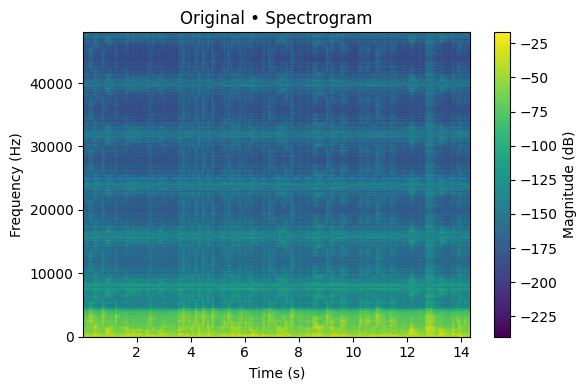

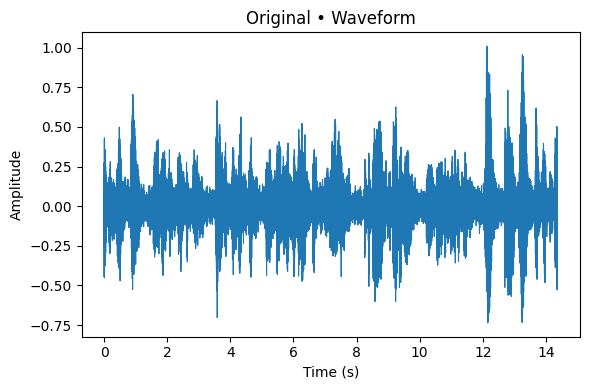

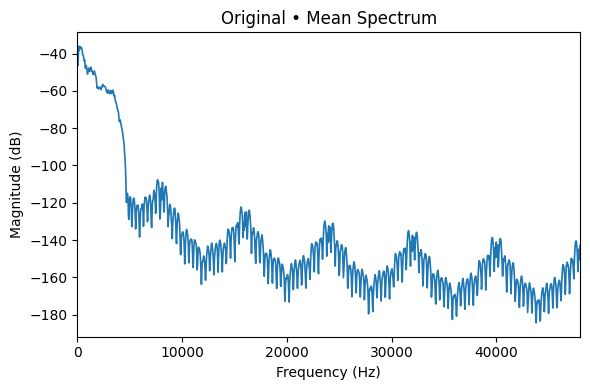

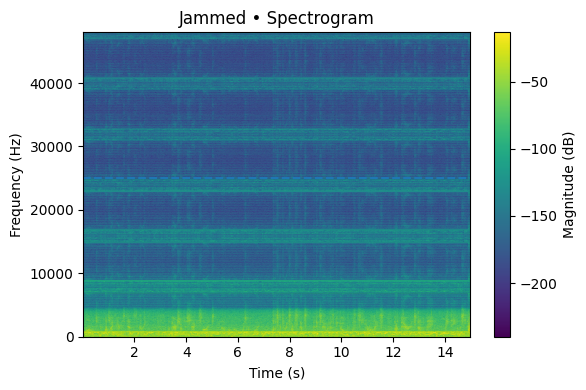

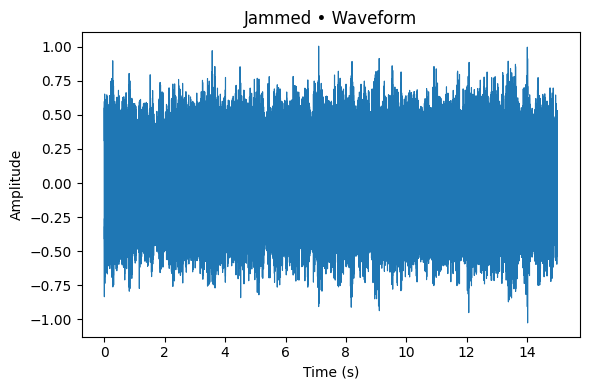

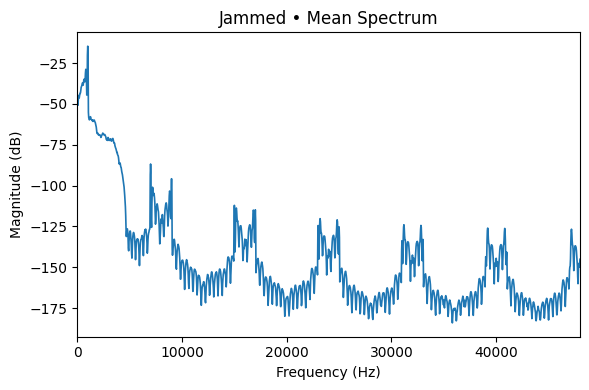

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

# ====== 설정 ======
ORIG_WAV = "/home/C_Weight/jaewoo_test/00micloaker/dataset/speaker.wav"
JAM_WAV  = "/home/C_Weight/jaewoo_test/00micloaker/dataset/jammed.wav"

TARGET_FS = 96000          # None이면 리샘플 안 함. 96 kHz 권장.
TONE_HZ   = 25000          # 기준선 표시 안 하려면 None

# 스펙트로그램 파라미터
WIN_SEC   = 0.032
HOP_SEC   = 0.008
WINDOW    = "hann"
EPS       = 1e-12

def load_wav_mono(path):
    fs, x = wavfile.read(path)
    if x.dtype.kind in "iu":
        maxv = np.iinfo(x.dtype).max
        x = x.astype(np.float32) / maxv
    else:
        x = x.astype(np.float32)
    if x.ndim == 2:
        x = x.mean(axis=1)
    return fs, x

def resample_if_needed(x, fs, target_fs):
    if target_fs is None or target_fs == fs:
        return fs, x
    g = np.gcd(fs, target_fs)
    up, down = target_fs // g, fs // g
    y = signal.resample_poly(x, up, down)
    return target_fs, y

def crop_or_pad_to_duration(x, fs, dur_sec):
    """길면 앞 15초로 자르고, 짧으면 0으로 패드."""
    if dur_sec is None:
        return x
    n_target = int(round(dur_sec * fs))
    if len(x) > n_target:
        return x[:n_target]
    elif len(x) < n_target:
        pad = np.zeros(n_target - len(x), dtype=x.dtype)
        return np.concatenate([x, pad], axis=0)
    else:
        return x

def plot_spectrogram(x, fs, title, tone_hz=None):
    nperseg = int(WIN_SEC * fs)
    noverlap = int((WIN_SEC - HOP_SEC) * fs)
    f, t, Sxx = signal.spectrogram(
        x, fs=fs, window=WINDOW, nperseg=nperseg, noverlap=noverlap,
        detrend=False, scaling="spectrum", mode="magnitude"
    )
    Sdb = 20*np.log10(Sxx + EPS)

    plt.figure(figsize=(6,4))
    plt.pcolormesh(t, f, Sdb, shading="gouraud")
    plt.colorbar(label="Magnitude (dB)")
    plt.ylim(0, fs/2)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    if tone_hz is not None and tone_hz < fs/2:
        plt.axhline(tone_hz, linestyle="--")
    plt.tight_layout()

def plot_waveform(x, fs, title):
    t = np.arange(len(x))/fs
    plt.figure(figsize=(6,4))
    plt.plot(t, x, linewidth=0.8)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.tight_layout()

def plot_mean_spectrum(x, fs, title):
    nperseg = int(WIN_SEC * fs)
    noverlap = int((WIN_SEC - HOP_SEC) * fs)
    f, t, Sxx = signal.spectrogram(
        x, fs=fs, window=WINDOW, nperseg=nperseg, noverlap=noverlap,
        detrend=False, scaling="spectrum", mode="magnitude"
    )
    mean_mag = np.mean(Sxx, axis=1)
    Sdb = 20*np.log10(mean_mag + EPS)

    plt.figure(figsize=(6,4))
    plt.plot(f, Sdb, linewidth=1.2)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(title)
    plt.xlim(0, fs/2)
    plt.tight_layout()

def analyze(path, tag, plot_dur_sec=None):
    fs, x = load_wav_mono(path)
    fs, x = resample_if_needed(x, fs, TARGET_FS)
    x = crop_or_pad_to_duration(x, fs, plot_dur_sec)

    # 1) 스펙트로그램
    plot_spectrogram(x, fs, f"{tag} • Spectrogram", tone_hz=TONE_HZ)
    # 2) 파형
    plot_waveform(x, fs, f"{tag} • Waveform")
    # 3) 평균 스펙트럼
    plot_mean_spectrum(x, fs, f"{tag} • Mean Spectrum")

# ====== 실행 ======
analyze(ORIG_WAV, "Original")                 # 전체 길이
analyze(JAM_WAV,  "Jammed", plot_dur_sec=15)  # Jammed만 15초
plt.show()


/tmp/ipykernel_9691/2378657584.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout()


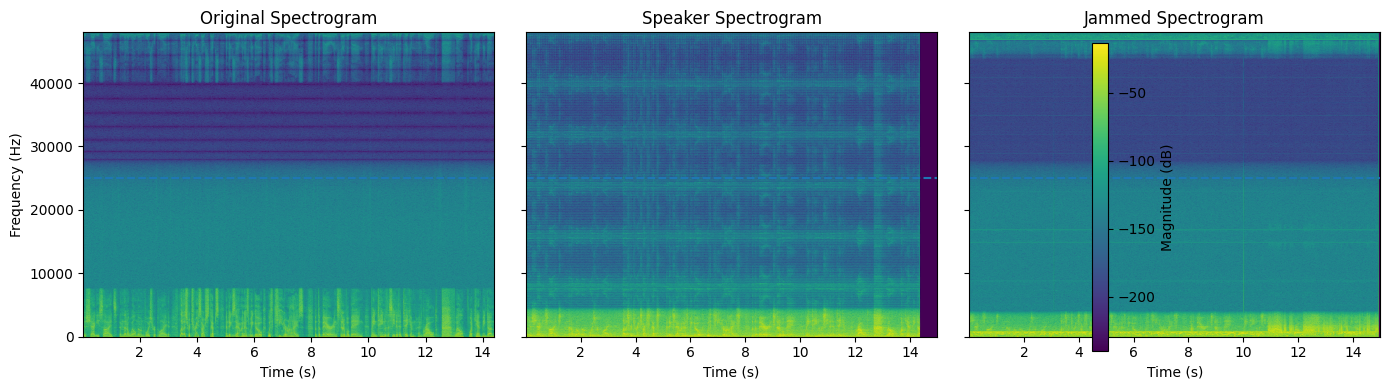

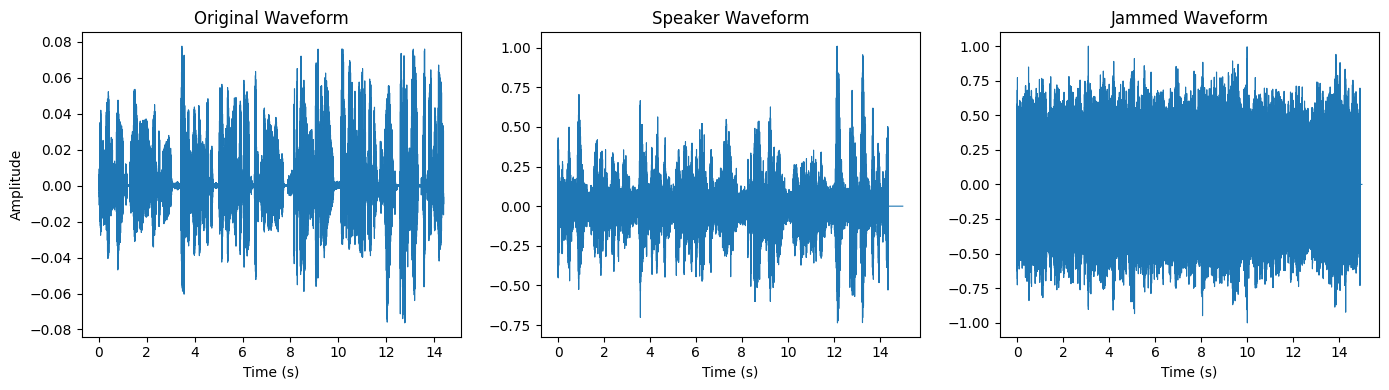

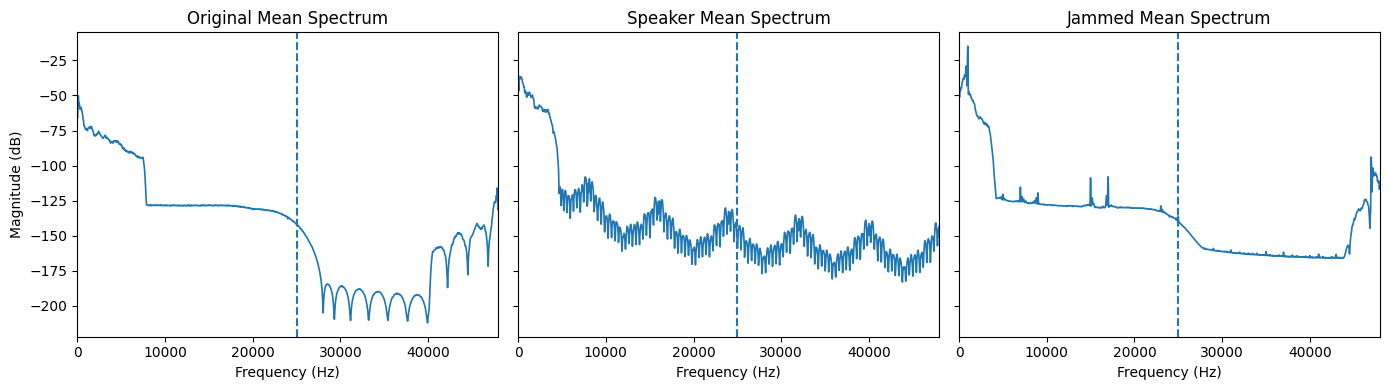

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ====== 설정 ======
ORIG_WAV = "/home/C_Weight/jaewoo_test/00micloaker/dataset/original.wav"
SPK_WAV  = "/home/C_Weight/jaewoo_test/00micloaker/dataset/speaker.wav"
JAM_WAV  = "/home/C_Weight/jaewoo_test/00micloaker/dataset/jammed.wav"

TARGET_FS = 96000          # None이면 리샘플 안 함. 96 kHz 권장.
TONE_HZ   = 25000          # 기준선 표시 안 하려면 None

# (길이 설정) 원본=전체, 스피커/재밍=15초로 자르기/패딩
PLOT_DUR_ORIG_SEC = None
PLOT_DUR_SPK_SEC  = 15.0
PLOT_DUR_JAM_SEC  = 15.0

# 스펙트로그램 파라미터
WIN_SEC   = 0.032
HOP_SEC   = 0.008
WINDOW    = "hann"
EPS       = 1e-12

# ====== 안전한 WAV 로더 (soundfile → librosa → scipy 순) ======
def load_wav_mono(path):
    # 1) soundfile (가장 관대, 헤더 이상에도 강함)
    try:
        import soundfile as sf
        x, fs = sf.read(path, dtype='float32', always_2d=False)
        if x.ndim == 2:         # (frames, channels)
            x = x.mean(axis=1)
        return fs, x.astype(np.float32)
    except Exception:
        pass

    # 2) librosa (백엔드에 따라 꽤 관대)
    try:
        import librosa
        y, fs = librosa.load(path, sr=None, mono=False)  # y: (n,) or (ch, n)
        if y.ndim == 1:
            x = y
        else:
            x = y.mean(axis=0)  # (ch, n) → (n,)
        return fs, x.astype(np.float32)
    except Exception:
        pass

    # 3) 최후: scipy (엄격. 여기서 또 터지면 파일 자체가 심각)
    from scipy.io import wavfile
    fs, x = wavfile.read(path)
    if x.dtype.kind in "iu":
        x = x.astype(np.float32) / np.iinfo(x.dtype).max
    else:
        x = x.astype(np.float32)
    if x.ndim == 2:
        x = x.mean(axis=1)
    return fs, x

def resample_if_needed(x, fs, target_fs):
    if target_fs is None or target_fs == fs:
        return fs, x
    g = np.gcd(fs, target_fs)
    up, down = target_fs // g, fs // g
    y = signal.resample_poly(x, up, down)
    return target_fs, y.astype(np.float32)

def crop_or_pad_to_duration(x, fs, dur_sec):
    if dur_sec is None:
        return x
    n_target = int(round(dur_sec * fs))
    if len(x) > n_target:
        return x[:n_target]
    elif len(x) < n_target:
        pad = np.zeros(n_target - len(x), dtype=x.dtype)
        return np.concatenate([x, pad], axis=0)
    else:
        return x

def spectrogram_db(x, fs):
    nperseg  = int(WIN_SEC * fs)
    noverlap = int((WIN_SEC - HOP_SEC) * fs)
    f, t, Sxx = signal.spectrogram(
        x, fs=fs, window=WINDOW, nperseg=nperseg, noverlap=noverlap,
        detrend=False, scaling="spectrum", mode="magnitude"
    )
    Sdb = 20*np.log10(Sxx + EPS)
    return f, t, Sdb

def mean_spectrum_db(x, fs):
    f, t, Sdb = spectrogram_db(x, fs)
    # magnitude 평균 후 dB로 변환
    mean_db = 20*np.log10(np.mean(10**(Sdb/20), axis=1) + EPS)
    return f, mean_db

# ====== 데이터 준비 (ORIG / SPK / JAM) ======
fs_o, x_o = load_wav_mono(ORIG_WAV)
fs_o, x_o = resample_if_needed(x_o, fs_o, TARGET_FS)
x_o = crop_or_pad_to_duration(x_o, fs_o, PLOT_DUR_ORIG_SEC)

fs_s, x_s = load_wav_mono(SPK_WAV)
fs_s, x_s = resample_if_needed(x_s, fs_s, TARGET_FS)
x_s = crop_or_pad_to_duration(x_s, fs_s, PLOT_DUR_SPK_SEC)

fs_j, x_j = load_wav_mono(JAM_WAV)
fs_j, x_j = resample_if_needed(x_j, fs_j, TARGET_FS)
x_j = crop_or_pad_to_duration(x_j, fs_j, PLOT_DUR_JAM_SEC)

# (안전) 샘플레이트 확인
if not (fs_o == fs_s == fs_j):
    print(f"[WARN] sample rates differ: orig={fs_o}, spk={fs_s}, jam={fs_j}")
FS = fs_o

# ====== 1) Spectrogram (Original / Speaker / Jammed) ======
f_o, t_o, Sdb_o = spectrogram_db(x_o, fs_o)
f_s, t_s, Sdb_s = spectrogram_db(x_s, fs_s)
f_j, t_j, Sdb_j = spectrogram_db(x_j, fs_j)

vmin = min(Sdb_o.min(), Sdb_s.min(), Sdb_j.min())
vmax = max(Sdb_o.max(), Sdb_s.max(), Sdb_j.max())

fig1, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
im0 = axes[0].pcolormesh(t_o, f_o, Sdb_o, shading="gouraud", vmin=vmin, vmax=vmax)
axes[0].set_title("Original Spectrogram")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_ylim(0, FS/2)
if TONE_HZ is not None and TONE_HZ < FS/2:
    axes[0].axhline(TONE_HZ, linestyle="--")

im1 = axes[1].pcolormesh(t_s, f_s, Sdb_s, shading="gouraud", vmin=vmin, vmax=vmax)
axes[1].set_title("Speaker Spectrogram")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylim(0, FS/2)
if TONE_HZ is not None and TONE_HZ < FS/2:
    axes[1].axhline(TONE_HZ, linestyle="--")

im2 = axes[2].pcolormesh(t_j, f_j, Sdb_j, shading="gouraud", vmin=vmin, vmax=vmax)
axes[2].set_title("Jammed Spectrogram")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylim(0, FS/2)
if TONE_HZ is not None and TONE_HZ < FS/2:
    axes[2].axhline(TONE_HZ, linestyle="--")

cbar = fig1.colorbar(im2, ax=axes.ravel().tolist())
cbar.set_label("Magnitude (dB)")
fig1.tight_layout()

# ====== 2) Waveform (Original / Speaker / Jammed) ======
fig2, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
t_o_w = np.arange(len(x_o))/fs_o
t_s_w = np.arange(len(x_s))/fs_s
t_j_w = np.arange(len(x_j))/fs_j

axes[0].plot(t_o_w, x_o, linewidth=0.8)
axes[0].set_title("Original Waveform")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(t_s_w, x_s, linewidth=0.8)
axes[1].set_title("Speaker Waveform")
axes[1].set_xlabel("Time (s)")

axes[2].plot(t_j_w, x_j, linewidth=0.8)
axes[2].set_title("Jammed Waveform")
axes[2].set_xlabel("Time (s)")

fig2.tight_layout()

# ====== 3) Mean Spectrum (Original / Speaker / Jammed) ======
fmo, ms_o = mean_spectrum_db(x_o, fs_o)
fms, ms_s = mean_spectrum_db(x_s, fs_s)
fmj, ms_j = mean_spectrum_db(x_j, fs_j)

fig3, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
axes[0].plot(fmo, ms_o, linewidth=1.2)
axes[0].set_title("Original Mean Spectrum")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude (dB)")
axes[0].set_xlim(0, FS/2)

axes[1].plot(fms, ms_s, linewidth=1.2)
axes[1].set_title("Speaker Mean Spectrum")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_xlim(0, FS/2)

axes[2].plot(fmj, ms_j, linewidth=1.2)
axes[2].set_title("Jammed Mean Spectrum")
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_xlim(0, FS/2)

if TONE_HZ is not None and TONE_HZ < FS/2:
    for ax in axes:
        ax.axvline(TONE_HZ, linestyle="--")

fig3.tight_layout()
plt.show()


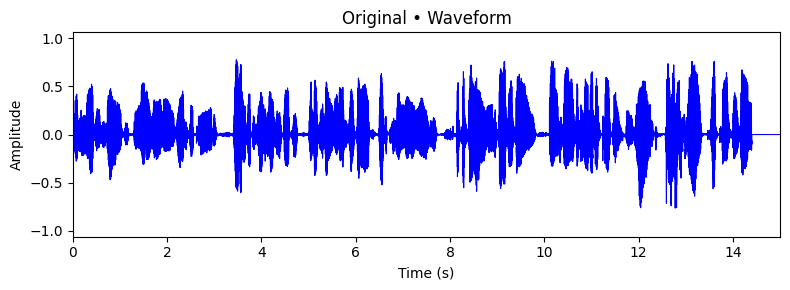

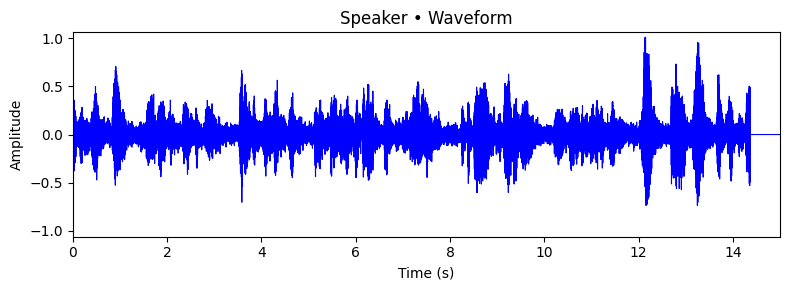

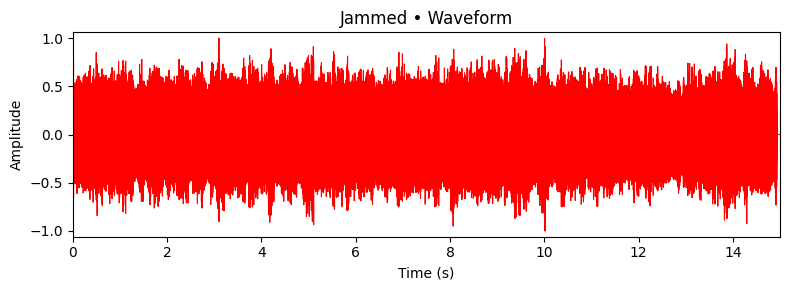

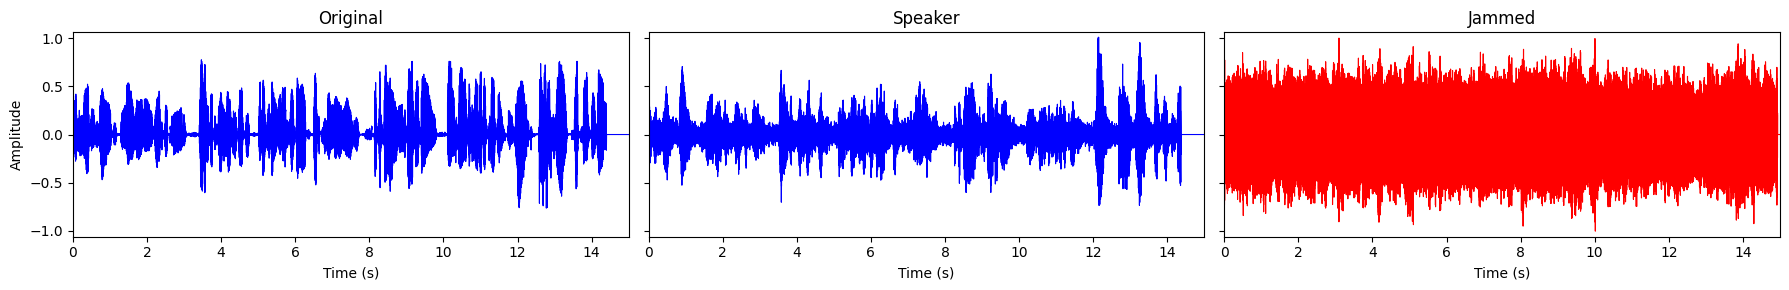

In [11]:
# === 위에서 정의한 load_wav_mono / resample_if_needed / crop_or_pad_to_duration 그대로 사용 ===

# ---- 데이터 로드 & 리샘플 ----
fs_o, x_o = load_wav_mono(ORIG_WAV)
fs_o, x_o = resample_if_needed(x_o, fs_o, TARGET_FS)

fs_s, x_s = load_wav_mono(SPK_WAV)
fs_s, x_s = resample_if_needed(x_s, fs_s, TARGET_FS)

fs_j, x_j = load_wav_mono(JAM_WAV)
fs_j, x_j = resample_if_needed(x_j, fs_j, TARGET_FS)

if not (fs_o == fs_s == fs_j):
    print(f"[WARN] sample rates differ: orig={fs_o}, spk={fs_s}, jam={fs_j}")
FS = fs_o

# ---- 15초로 맞추기(부족하면 0 패딩) ----
DUR = 15.0
x_o_15 = crop_or_pad_to_duration(x_o, FS, DUR)
x_s_15 = crop_or_pad_to_duration(x_s, FS, DUR)
x_j_15 = crop_or_pad_to_duration(x_j, FS, DUR)

x_o_15 = x_o_15*10
t_o = np.arange(len(x_o_15)) / FS
t_s = np.arange(len(x_s_15)) / FS
t_j = np.arange(len(x_j_15)) / FS

# 공통 y축 범위(비교를 위해 동일하게)
ylim = 1.05 * max(np.max(np.abs(x_o_15)), np.max(np.abs(x_s_15)), np.max(np.abs(x_j_15)))

# ===== 1) Original 단독 =====
plt.figure(figsize=(8, 3))
plt.plot(t_o, x_o_15, color='blue', linewidth=0.8)
plt.xlim(0, DUR)
plt.ylim(-ylim, ylim)
plt.title("Original • Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()

# ===== 3) speaker 단독 =====
plt.figure(figsize=(8, 3))
plt.plot(t_s, x_s_15, color='blue', linewidth=0.8)
plt.xlim(0, DUR)
plt.ylim(-ylim, ylim)
plt.title("Speaker • Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()

# ===== 2) Jammed 단독 =====
plt.figure(figsize=(8, 3))
plt.plot(t_j, x_j_15, color='red', linewidth=0.8)
plt.xlim(0, DUR)
plt.ylim(-ylim, ylim)
plt.title("Jammed • Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()


# ===== 3) 좌: Original / 중: Speaker / 우: Jammed =====
fig, axes = plt.subplots(1, 3, figsize=(18, 3), sharey=True)

axes[0].plot(t_o, x_o_15, color='blue', linewidth=0.8)
axes[0].set_xlim(0, DUR); axes[0].set_ylim(-ylim, ylim)
axes[0].set_title("Original")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude")

axes[1].plot(t_s, x_s_15, color='blue', linewidth=0.8)
axes[1].set_xlim(0, DUR); axes[1].set_ylim(-ylim, ylim)
axes[1].set_title("Speaker")
axes[1].set_xlabel("Time (s)")

axes[2].plot(t_j, x_j_15, color='red', linewidth=0.8)
axes[2].set_xlim(0, DUR); axes[2].set_ylim(-ylim, ylim)
axes[2].set_title("Jammed")
axes[2].set_xlabel("Time (s)")

fig.tight_layout()
plt.show()


In [2]:
# -*- coding: utf-8 -*-
# 필요한 패키지: numpy, matplotlib, scipy, pillow
# 없으면: pip install numpy matplotlib scipy pillow

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.io import wavfile
from scipy import signal
from pathlib import Path

# =========================
#        설정
# =========================
REAL_WAV = "/home/C_Weight/jaewoo_test/00micloaker/dataset/original.wav"
ORIG_WAV = "/home/C_Weight/jaewoo_test/00micloaker/dataset/speaker.wav"
JAM_WAV  = "/home/C_Weight/jaewoo_test/00micloaker/dataset/jammed.wav"

TARGET_FS = 96000      # 25 kHz 톤 보려면 96 kHz 권장. None이면 리샘플 안 함
DUR       = 15.0       # GIF 길이(초) — 부족하면 0 패딩, 길면 잘라냄
FPS       = 24         # GIF 프레임레이트
WINDOW_SEC= 15.0        # mode="sliding"일 때 한 프레임에 보일 시간 구간 길이(초)
FIGSIZE   = (16, 3)    # 그림 크기(인치)
DPI       = 100        # 해상도 (픽셀 = 인치 * DPI)
OUT_DIR   = Path(".")  # 출력 폴더
REAL_GAIN = 10.0     # ✅ real_waveform 시각적 볼륨(진폭) 스케일 팩터

# =========================
#      유틸 함수들
# =========================
def load_wav_mono(path):
    # 1) soundfile로 먼저 시도 (헤더 불일치에도 관대함)
    try:
        import soundfile as sf
        x, fs = sf.read(path, dtype="float32", always_2d=False)
    except Exception as e:
        # 2) 실패 시 scipy로 폴백 (여전히 실패할 수도 있음)
        from scipy.io import wavfile
        fs, x = wavfile.read(path)
        if x.dtype.kind in "iu":
            maxv = np.iinfo(x.dtype).max
            x = x.astype(np.float32) / maxv
        else:
            x = x.astype(np.float32)

    if x.ndim == 2:
        x = x.mean(axis=1)
    return fs, x


def resample_if_needed(x, fs, target_fs):
    if target_fs is None or target_fs == fs:
        return fs, x
    g = np.gcd(fs, target_fs)
    up, down = target_fs // g, fs // g
    y = signal.resample_poly(x, up, down)
    return target_fs, y

def crop_or_pad_to_duration(x, fs, dur_sec):
    n_target = int(round(dur_sec * fs))
    if len(x) > n_target:
        return x[:n_target]
    elif len(x) < n_target:
        pad = np.zeros(n_target - len(x), dtype=x.dtype)
        return np.concatenate([x, pad], axis=0)
    else:
        return x

# =========================
#     GIF 생성 함수
# =========================
def make_waveform_gif(x, fs, out_path,
                      dur_sec=15.0, fps=24,
                      mode="sliding",      # "sliding" 또는 "cumulative"
                      window_sec=15,      # sliding 모드에서 창 길이(초)
                      ylim=None,
                      figsize=(16,3), dpi=100):
    """
    x: wave (mono, float)
    fs: sample rate
    out_path: 저장 경로 (.gif)
    dur_sec: GIF 총 길이(초) - 부족하면 0 패드, 길면 잘라냄
    fps: 초당 프레임 수 (GIF 프레임레이트 & 업데이트 주기)
    mode: "sliding" -> 이동창만 그려줌 / "cumulative" -> 0~t까지 누적
    window_sec: sliding 모드에서 한 프레임에 보일 시간 구간 길이
    ylim: None | 스칼라 | (ymin, ymax)
    figsize: (가로, 세로) 인치 단위
    dpi: 해상도 (픽셀=인치*dpi)
    """
    # 길이 맞추기
    n_target = int(round(dur_sec * fs))
    if len(x) > n_target:
        x = x[:n_target]
    elif len(x) < n_target:
        x = np.concatenate([x, np.zeros(n_target - len(x), dtype=x.dtype)], axis=0)

    t = np.arange(len(x)) / fs

    # ylim 정규화
    def _normalize_ylim(ylim_in, x_in):
        if ylim_in is None:
            yabs = float(np.max(np.abs(x_in)) + 1e-9)
            return (-1.05*yabs, 1.05*yabs)
        if np.isscalar(ylim_in):
            yabs = float(abs(ylim_in))
            return (-yabs, yabs)
        lo, hi = float(ylim_in[0]), float(ylim_in[1])
        if lo == hi:
            eps = 1e-6 if hi == 0 else 1e-3*abs(hi)
            lo, hi = lo - eps, hi + eps
        return (lo, hi)

    ylim = _normalize_ylim(ylim, x)

    # 프레임/스텝
    n_frames = max(1, int(np.ceil(dur_sec * fps)))
    hop = max(1, int(np.ceil(fs / fps)))
    win = max(1, int(round(window_sec * fs)))

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ln, = ax.plot([], [], linewidth=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_ylim(ylim)
    ax.set_xlim(0, dur_sec)   # ✅ x축 0~dur_sec 고정 (안 움직이게)

    def init():
        ln.set_data([], [])
        ax.set_title("")
        return ln,

    def update(i):
        idx_end = min((i+1)*hop, len(x))
        if mode == "cumulative":
            xdata = t[:idx_end]
            ydata = x[:idx_end]
        else:  # sliding
            idx_start = max(0, idx_end - win)
            xdata = t[idx_start:idx_end]
            ydata = x[idx_start:idx_end]

        ln.set_data(xdata, ydata)
        ax.set_title(f"Waveform • t = {idx_end/fs:5.2f} s  ({mode}, x-axis fixed)")
        return ln,

    anim = FuncAnimation(fig, update, init_func=init,
                         frames=n_frames, interval=1000/fps, blit=True)
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    anim.save(str(OUT_DIR / out_path), writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"[OK] saved: {OUT_DIR/out_path}")

# =========================
#         실행
# =========================
# 1) 로드 & 리샘플 (세 파일 모두)
fs_o, x_o = load_wav_mono(ORIG_WAV)
fs_o, x_o = resample_if_needed(x_o, fs_o, TARGET_FS)

fs_j, x_j = load_wav_mono(JAM_WAV)
fs_j, x_j = resample_if_needed(x_j, fs_j, TARGET_FS)

fs_r, x_r = load_wav_mono(REAL_WAV)
fs_r, x_r = resample_if_needed(x_r, fs_r, TARGET_FS)
x_r = x_r * REAL_GAIN    # ✅ real_waveform만 진폭 키움

if len({fs_o, fs_j, fs_r}) != 1:
    print(f"[WARN] sample rates differ: orig={fs_o}, jam={fs_j}, real={fs_r}")

# 2) 각 신호를 DUR로 맞추기 (각자의 fs 사용)
x_o_15 = crop_or_pad_to_duration(x_o, fs_o, DUR)
x_j_15 = crop_or_pad_to_duration(x_j, fs_j, DUR)
x_r_15 = crop_or_pad_to_duration(x_r, fs_r, DUR)

# 3) 공통 y축 범위 계산(세 신호 모두 고려)
yabs = float(1.05 * max(np.max(np.abs(x_o_15)),
                        np.max(np.abs(x_j_15)),
                        np.max(np.abs(x_r_15))))
YLIM = (-yabs, yabs)

# 4) GIF 생성
make_waveform_gif(
    x_r_15, fs_r, out_path="real_waveform_15s.gif",
    dur_sec=DUR, fps=FPS, mode="sliding", window_sec=WINDOW_SEC,
    ylim=YLIM, figsize=FIGSIZE, dpi=DPI
)
make_waveform_gif(
    x_o_15, fs_o, out_path="original_waveform_15s.gif",
    dur_sec=DUR, fps=FPS, mode="sliding", window_sec=WINDOW_SEC,
    ylim=YLIM, figsize=FIGSIZE, dpi=DPI
)
make_waveform_gif(
    x_j_15, fs_j, out_path="jammed_waveform_15s.gif",
    dur_sec=DUR, fps=FPS, mode="sliding", window_sec=WINDOW_SEC,
    ylim=YLIM, figsize=FIGSIZE, dpi=DPI
)



# (옵션) 누적 모드
# make_waveform_gif(x_o_15, fs_o, "original_waveform_15s_cum.gif",
#                   dur_sec=DUR, fps=FPS, mode="cumulative", ylim=YLIM,
#                   figsize=FIGSIZE, dpi=DPI)
# make_waveform_gif(x_j_15, fs_j, "jammed_waveform_15s_cum.gif",
#                   dur_sec=DUR, fps=FPS, mode="cumulative", ylim=YLIM,
#                   figsize=FIGSIZE, dpi=DPI)
# make_waveform_gif(x_r_15, fs_r, "real_waveform_15s_cum.gif",
#                   dur_sec=DUR, fps=FPS, mode="cumulative", ylim=YLIM,
#                   figsize=FIGSIZE, dpi=DPI)



[OK] saved: real_waveform_15s.gif
[OK] saved: original_waveform_15s.gif
[OK] saved: jammed_waveform_15s.gif


In [2]:
# deps:
# pip install -U openai-whisper opencv-python
# (CPU면) pip install --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio

import cv2, math, re
import numpy as np
import whisper

# ── 모델 1회 로드 ─────────────────────────────────────────────
model = whisper.load_model("large-v3")

def word_timestamps(audio_path, lang="en"):
    """Whisper로 단어 타임스탬프 [(s,e,word)], 총길이 반환. (단어 타임스탬프 없으면 균등분배)"""
    kw = dict(language=lang, word_timestamps=True, verbose=False)
    try:
        import torch
        if not torch.cuda.is_available():
            kw["fp16"] = False
    except Exception:
        kw["fp16"] = False

    r = model.transcribe(audio_path, **kw)
    words, last_end = [], 0.0
    for seg in r.get("segments", []):
        if seg.get("words"):
            for w in seg["words"]:
                s = float(max(0.0, w.get("start", seg["start"])))
                e = float(max(s,     w.get("end",   seg["end"])))
                t = w.get("word", "").strip()
                if t:
                    words.append((s,e,t))
                    last_end = max(last_end, e)
        else:
            # fallback: 세그먼트 전체를 단어 수로 균등 분배
            text = re.sub(r"\s+", " ", seg.get("text","").strip())
            toks = [x for x in text.split(" ") if x]
            if not toks: continue
            s0, e0 = float(seg["start"]), float(seg["end"])
            dur = max(1e-3, (e0 - s0) / len(toks))
            for i, t in enumerate(toks):
                s = s0 + i*dur
                e = min(e0, s+dur)
                words.append((s,e,t))
                last_end = max(last_end, e)
    return words, (last_end or float(r.get("duration", 0.0) or 0.0))

def render_highlight_video(audio_path, out_mp4,
                           size=(1280, 360), fps=30,
                           base=(160,160,160), hi=(255,255,255), bg=(0,0,0),
                           font=cv2.FONT_HERSHEY_SIMPLEX, font_scale=1.1, thick=2):
    """오디오 없이, 단어가 말해질 때만 색(hi)으로 바뀌는 자막 비디오 생성"""
    W, H = size
    words, duration = word_timestamps(audio_path)
    text_words = [re.sub(r"\s+", " ", w).strip() for _,_,w in words if w.strip()]

    # 줄바꿈(폭 기준 간단 배치)
    margin, gap = 40, 18
    lines, line = [], []
    x, y = margin, margin
    lh = cv2.getTextSize("Ag", font, font_scale, thick)[0][1]*2  # 대략 라인 높이
    for w in text_words:
        (tw, _), _ = cv2.getTextSize(w, font, font_scale, thick)
        if x + tw + margin > W:
            lines.append(line); line=[]; x=margin; y+=lh+gap
        line.append((w, (x, y))); x += tw + 20
    if line: lines.append(line)

    # 각 단어에 타임스탬프 매칭(배치 순서 = 발화 순서 가정)
    idx, placement = 0, []
    for li, ln in enumerate(lines):
        for wi, (w, pos) in enumerate(ln):
            if idx < len(words):
                s,e,_ = words[idx]; placement.append((li, wi, pos, s, e, w)); idx+=1

    vw = cv2.VideoWriter(str(out_mp4), cv2.VideoWriter_fourcc(*"mp4v"), fps, (W,H))
    assert vw.isOpened(), "VideoWriter open failed."

    total_frames = max(1, int(math.ceil(duration*fps)))
    for f in range(total_frames):
        t = f / fps
        frame = np.full((H, W, 3), bg, dtype=np.uint8)
        for _, _, (x,y), s,e,w in placement:
            color = hi if (s <= t < e) else base
            cv2.putText(frame, w, (x, y), font, font_scale, color, thick, cv2.LINE_AA)
        vw.write(frame)
    vw.release()

# ── 사용 예시(무음 mp4 생성) ───────────────────────────────────
render_highlight_video("speaker.wav", "speaker_highlight.mp4")
render_highlight_video("jammed.wav",  "jammed_highlight.mp4")


RuntimeError: Failed to load audio: ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --e